# 01 - EDA e Qualidade de Fontes

Objetivo: medir o calor das fontes com uma base causal e sem inflar sistemas por multiplas aparicoes do mesmo telefone.

Premissas principais:
- Excluir status intermediario `processing`.
- Excluir telefones fixos com filtro case-insensitive.
- Usar entrega como metrica operacional: `delivered` ou `read`.
- Usar leitura como metrica de negocio e diagnostico.
- Deduplicar aparicoes para uma linha por `(telefone_numero, id_sistema)`.


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportion_confint

import utils as u

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

print('Imports OK')


Imports OK


## 1. Carregamento e filtros

Esta etapa aplica as regras de limpeza antes de qualquer join ou ranking.


In [2]:
df_disparo_raw, df_telefone_raw = u.carregar_dados()

df_disparo = u.filtrar_status_invalidos(df_disparo_raw)
df_telefone = u.filtrar_telefones_fixos(df_telefone_raw)

print('Disparos raw:', df_disparo_raw.shape)
print('Disparos validos:', df_disparo.shape)
print('Telefones raw:', df_telefone_raw.shape)
print('Telefones validos:', df_telefone.shape)
print('\nStatus validos:')
print(df_disparo['status_disparo'].value_counts(dropna=False))
print('\nTipos de telefone apos filtro:')
print(df_telefone['telefone_tipo'].value_counts(dropna=False))


Filtrando status intermediarios: 392,921 -> 389,761 (-3,160)
Filtrando telefones fixos: 283,289 -> 283,281 (-8)
Disparos raw: (392921, 16)
Disparos validos: (389761, 16)
Telefones raw: (283289, 11)
Telefones validos: (283281, 12)

Status validos:
status_disparo
read         271566
delivered     85405
failed        27257
sent           5533
Name: count, dtype: int64[pyarrow]

Tipos de telefone apos filtro:
telefone_tipo
CELULAR    283281
Name: count, dtype: int64


## 2. Aparicoes: brutas, por fonte e por CPF

A visao por fonte evita que um telefone com muitas aparicoes no mesmo sistema conte varias vezes no ranking da fonte.


In [3]:
df_aparicoes_brutas = u.explodir_aparicoes(df_telefone)
df_aparicoes_fonte = u.preparar_aparicoes_por_fonte(df_aparicoes_brutas)
df_telefone_cpf = u.preparar_telefone_cpf(df_aparicoes_brutas)

resumo_aparicoes = pd.DataFrame({
    'visao': ['bruta', 'por_fonte', 'telefone_cpf'],
    'linhas': [len(df_aparicoes_brutas), len(df_aparicoes_fonte), len(df_telefone_cpf)],
    'telefones': [df_aparicoes_brutas['telefone_numero'].nunique(), df_aparicoes_fonte['telefone_numero'].nunique(), df_telefone_cpf['telefone_numero'].nunique()],
})
display(resumo_aparicoes)
print('Reducao de linhas bruta -> por_fonte:', f"{1 - len(df_aparicoes_fonte) / len(df_aparicoes_brutas):.2%}")


Telefones unicos: 283,281
Aparicoes brutas: 1,522,742
Sistemas unicos: 6
Aparicoes por fonte deduplicadas: 592,728
Pares telefone-CPF candidatos: 1,246,889


,visao,linhas,telefones
0,bruta,1522742,283281
1,por_fonte,592728,283281
2,telefone_cpf,1246889,283281


Reducao de linhas bruta -> por_fonte: 61.07%


## 3. Join causal disparo x sistema

Para o ranking, uma fonte so recebe credito se o telefone ja existia naquela fonte antes do envio.


In [4]:
df_disparo_sistema = u.join_disparo_sistema(df_disparo, df_aparicoes_fonte, causal=True)

colunas_preview = [
    'id_disparo', 'cpf', 'contato_telefone', 'id_sistema',
    'status_disparo', 'envio_datahora', 'registro_data_atualizacao'
]
display(df_disparo_sistema[colunas_preview].head(10))


Disparos com match: 329,163 / 389,761
Total de linhas apos join: 634,215
Multiplicidade media: 1.93x


,id_disparo,cpf,contato_telefone,id_sistema,status_disparo,envio_datahora,registro_data_atualizacao
3,-2125284141464109242,NaN,-1594807689860738862,1257277410380486863,sent,2025-09-18 16:52:11,2024-11-08
4,7300265916938298489,NaN,5602817034559087705,3094574413675758272,sent,2025-09-18 16:52:13,2025-06-20
5,7300265916938298489,NaN,5602817034559087705,4458959843028638627,sent,2025-09-18 16:52:13,2025-03-27
7,9151126386650565149,NaN,9135457062930065765,3094574413675758272,sent,2025-09-18 16:52:17,2024-08-22
8,9151126386650565149,NaN,9135457062930065765,4458959843028638627,sent,2025-09-18 16:52:17,2025-03-22
11,6689274410204799409,NaN,8082769678190242092,4458959843028638627,sent,2025-09-19 14:17:24,2025-03-25
12,2505795430415096579,NaN,1307114207107446969,4458959843028638627,sent,2025-09-19 14:17:25,2025-03-25
13,8669484436982267605,NaN,-3836909583120964120,1257277410380486863,sent,2025-09-19 14:17:29,2025-06-20
14,-8425273151875880324,NaN,-3143777526667886344,1257277410380486863,sent,2025-09-19 14:17:31,2024-12-26
15,-122545644729800206,NaN,499872315073148475,4458959843028638627,sent,2025-09-19 14:17:31,2025-03-25


## 4. Ranking de sistemas por entrega

O ranking usa Wilson lower bound de entrega para penalizar baixo volume.


,id_sistema,total_disparos,sucessos_entrega,taxa_entrega,taxa_leitura,taxa_falha,wilson_lower_entrega,score_sistema
0,-4704067261970591609,195363,193982,0.992931,0.777450,0.002570,0.992550,1.000000
1,-2757366171786647144,6796,6560,0.965274,0.686580,0.023690,0.960651,0.302084
2,3094574413675758272,242119,231481,0.956063,0.743424,0.032327,0.955239,0.183674
3,4458959843028638627,19694,18760,0.952574,0.718290,0.027623,0.949517,0.058466
4,-133612832286195827,20434,19448,0.951747,0.737741,0.035921,0.948723,0.041101
5,1257277410380486863,149809,142016,0.947980,0.711806,0.040218,0.946844,0.000000


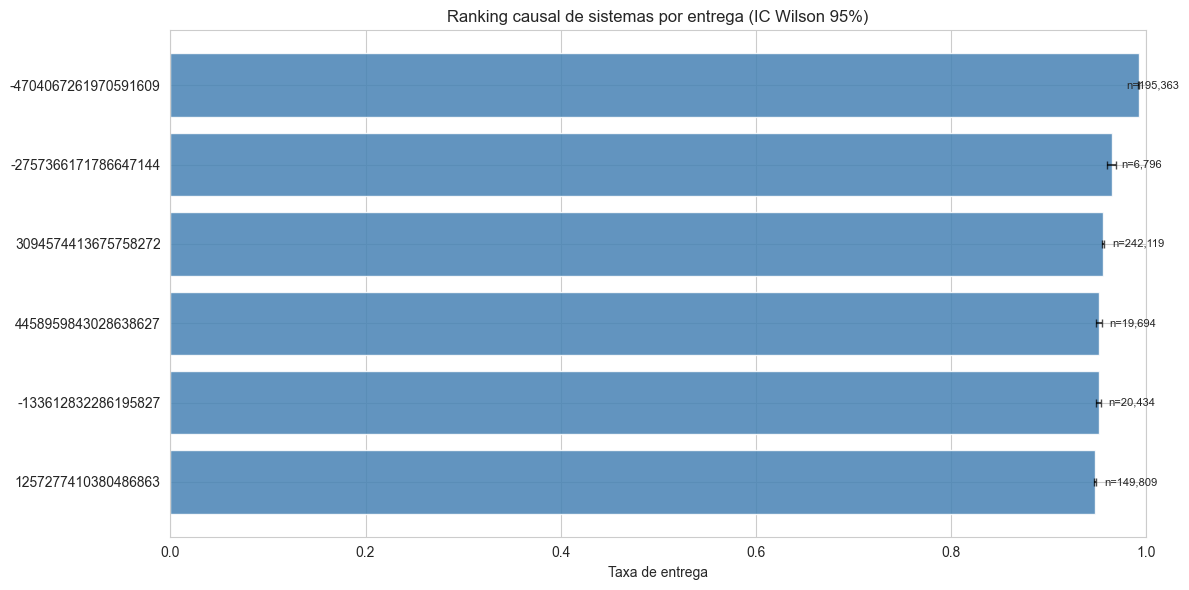

In [5]:
metricas_sistema = u.calcular_metricas_sistema(df_disparo_sistema)
metricas_sistema = u.calcular_score_sistema(metricas_sistema)

cols = [
    'id_sistema', 'total_disparos', 'sucessos_entrega', 'taxa_entrega',
    'taxa_leitura', 'taxa_falha', 'wilson_lower_entrega', 'score_sistema'
]
display(metricas_sistema[cols])

top = metricas_sistema.head(15).copy()
top[['ci_low', 'ci_high']] = top.apply(
    lambda row: pd.Series(proportion_confint(row['sucessos_entrega'], row['total_disparos'], alpha=0.05, method='wilson')),
    axis=1,
)

fig, ax = plt.subplots(figsize=(12, 6))
y_pos = np.arange(len(top))
ax.barh(y_pos, top['taxa_entrega'], color='steelblue', alpha=0.85)
ax.errorbar(
    top['taxa_entrega'], y_pos,
    xerr=[top['taxa_entrega'] - top['ci_low'], top['ci_high'] - top['taxa_entrega']],
    fmt='none', color='black', capsize=3, alpha=0.7,
)
ax.set_yticks(y_pos)
ax.set_yticklabels(top['id_sistema'])
ax.invert_yaxis()
ax.set_xlabel('Taxa de entrega')
ax.set_title('Ranking causal de sistemas por entrega (IC Wilson 95%)')
ax.set_xlim(0, 1)
for i, (_, row) in enumerate(top.iterrows()):
    ax.text(min(row['taxa_entrega'] + 0.01, 0.98), i, f"n={row['total_disparos']:,}", va='center', fontsize=8)
plt.tight_layout()
plt.show()


## 5. Decaimento temporal

Avaliamos se a idade do dado reduz a chance de entrega.


,faixa_atualizacao,total,read,delivered,failed,sucessos_entrega,taxa_entrega,taxa_leitura
0,<30d,7219,5498,1596,72,7094,0.982685,0.761601
1,30-90d,28429,21428,6288,493,27716,0.974920,0.753737
2,90-180d,216455,165871,46483,2629,212354,0.981054,0.766307
3,180d-1a,96329,69020,22179,3494,91199,0.946745,0.716503
4,1-2a,86398,61455,19883,3836,81338,0.941434,0.711301
5,>2a,74379,52009,17411,4190,69420,0.933328,0.699243


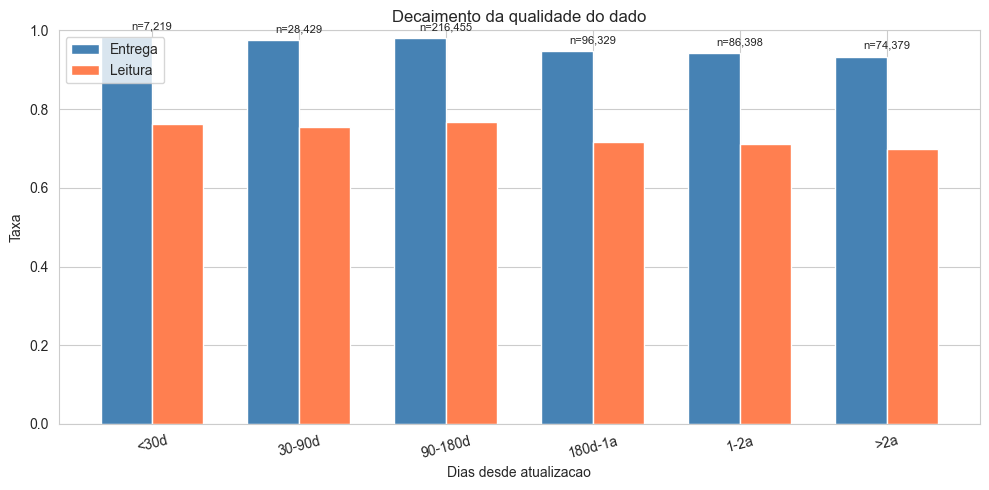

Chi-square: 5421.94
p-valor: 0.00e+00


In [6]:
decaimento = u.calcular_decaimento_temporal(df_disparo_sistema)
display(decaimento)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(decaimento))
width = 0.35
ax.bar(x - width/2, decaimento['taxa_entrega'], width, label='Entrega', color='steelblue')
ax.bar(x + width/2, decaimento['taxa_leitura'], width, label='Leitura', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(decaimento['faixa_atualizacao'], rotation=15)
ax.set_ylim(0, 1)
ax.set_ylabel('Taxa')
ax.set_xlabel('Dias desde atualizacao')
ax.set_title('Decaimento da qualidade do dado')
ax.legend()
for i, row in decaimento.iterrows():
    if pd.notna(row['total']):
        ax.text(i, max(row['taxa_entrega'], row['taxa_leitura']) + 0.02, f"n={int(row['total']):,}", ha='center', fontsize=8)
plt.tight_layout()
plt.show()

contingencia = decaimento[['sucessos_entrega']].copy()
contingencia['nao_entrega'] = decaimento['total'] - decaimento['sucessos_entrega']
contingencia = contingencia.dropna()
if len(contingencia) > 1:
    chi2, p_valor, dof, esperado = stats.chi2_contingency(contingencia.values)
    print(f'Chi-square: {chi2:.2f}')
    print(f'p-valor: {p_valor:.2e}')
else:
    print('Sem faixas suficientes para teste chi-square.')


## 6. Sinais de vies de selecao

Comparamos volume, first-touch e vitorias intra-CPF para separar qualidade real de pre-selecao historica.


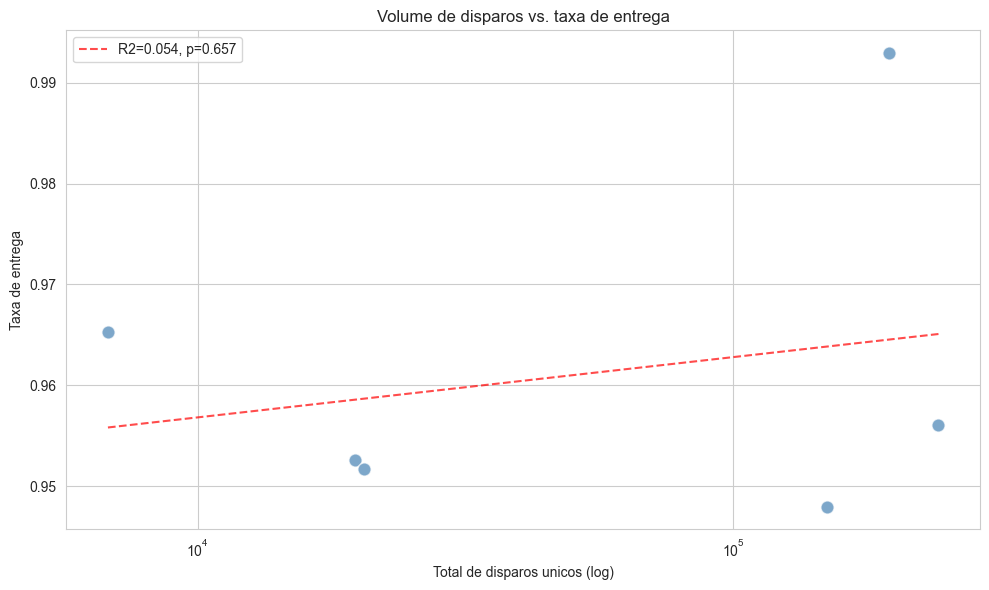

Correlacao Pearson (log volume vs taxa): R=0.233, p=0.657


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(metricas_sistema['total_disparos'], metricas_sistema['taxa_entrega'], s=90, alpha=0.7, color='steelblue', edgecolors='white')
log_vol = np.log10(metricas_sistema['total_disparos'])
slope, intercept, r_value, p_value, std_err = stats.linregress(log_vol, metricas_sistema['taxa_entrega'])
x_fit = np.linspace(metricas_sistema['total_disparos'].min(), metricas_sistema['total_disparos'].max(), 100)
y_fit = slope * np.log10(x_fit) + intercept
ax.plot(x_fit, y_fit, 'r--', alpha=0.7, label=f'R2={r_value**2:.3f}, p={p_value:.3f}')
ax.set_xscale('log')
ax.set_xlabel('Total de disparos unicos (log)')
ax.set_ylabel('Taxa de entrega')
ax.set_title('Volume de disparos vs. taxa de entrega')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Correlacao Pearson (log volume vs taxa): R={r_value:.3f}, p={p_value:.3f}')


In [8]:
df_first = (
    df_disparo.sort_values('envio_datahora')
    .drop_duplicates(subset='contato_telefone', keep='first')
)
df_first_sistema = u.join_disparo_sistema(df_first, df_aparicoes_fonte, causal=True)
metricas_first = u.calcular_score_sistema(u.calcular_metricas_sistema(df_first_sistema))

comparacao_first = metricas_sistema[['id_sistema', 'wilson_lower_entrega', 'taxa_entrega']].merge(
    metricas_first[['id_sistema', 'wilson_lower_entrega', 'taxa_entrega']],
    on='id_sistema', how='outer', suffixes=('_geral', '_first')
)
comparacao_first['rank_geral'] = comparacao_first['wilson_lower_entrega_geral'].rank(ascending=False)
comparacao_first['rank_first'] = comparacao_first['wilson_lower_entrega_first'].rank(ascending=False)
comparacao_first['delta_rank'] = comparacao_first['rank_geral'] - comparacao_first['rank_first']

display(comparacao_first.sort_values('rank_first'))


Disparos com match: 240,538 / 293,342
Total de linhas apos join: 448,305
Multiplicidade media: 1.86x


,id_sistema,wilson_lower_entrega_geral,taxa_entrega_geral,wilson_lower_entrega_first,taxa_entrega_first,rank_geral,rank_first,delta_rank
2,-4704067261970591609,0.992550,0.992931,0.996951,0.997246,1.0,1.0,0.0
1,-2757366171786647144,0.960651,0.965274,0.967710,0.972782,2.0,2.0,0.0
4,3094574413675758272,0.955239,0.956063,0.961621,0.962522,3.0,3.0,0.0
0,-133612832286195827,0.948723,0.951747,0.958051,0.961297,5.0,4.0,1.0
5,4458959843028638627,0.949517,0.952574,0.954720,0.958479,4.0,5.0,-1.0
3,1257277410380486863,0.946844,0.947980,0.952981,0.954244,6.0,6.0,0.0


In [9]:
cpf_sistema = (
    df_disparo_sistema.dropna(subset=['cpf'])
    .groupby(['cpf', 'id_sistema'])
    .agg(
        total=('id_disparo', 'nunique'),
        entregas=('status_disparo', lambda s: s.isin(u.STATUS_ENTREGA).sum()),
        leituras=('status_disparo', lambda s: (s == 'read').sum()),
    )
    .reset_index()
)
cpf_sistema['taxa_entrega'] = cpf_sistema['entregas'] / cpf_sistema['total']
cpf_multi = cpf_sistema.groupby('cpf')['id_sistema'].nunique().loc[lambda s: s >= 2].index
cpf_rank = cpf_sistema[cpf_sistema['cpf'].isin(cpf_multi)].copy()
cpf_rank['rank_no_cpf'] = cpf_rank.groupby('cpf')['taxa_entrega'].rank(ascending=False, method='first')

vitorias = cpf_rank[cpf_rank['rank_no_cpf'] == 1].groupby('id_sistema').size().reset_index(name='vitorias')
participacoes = cpf_rank.groupby('id_sistema').size().reset_index(name='participacoes')
vitorias = vitorias.merge(participacoes, on='id_sistema', how='outer').fillna(0)
vitorias['taxa_vitoria'] = np.where(vitorias['participacoes'] > 0, vitorias['vitorias'] / vitorias['participacoes'], np.nan)
vitorias = vitorias.sort_values('taxa_vitoria', ascending=False)

display(vitorias)


,id_sistema,vitorias,participacoes,taxa_vitoria
0,-133612832286195827,13312,13400,0.993433
2,-4704067261970591609,110797,121005,0.915640
1,-2757366171786647144,3396,3738,0.908507
3,1257277410380486863,23285,83372,0.279290
4,3094574413675758272,2350,135557,0.017336
5,4458959843028638627,16,12116,0.001321


## 6.1 Desempenho por Categoria de Campanha

Sistemas podem performar diferentemente conforme o tipo de campanha (saude, educacao, IPTU etc.). Esta secao verifica se o ranking causal se susta quando estratificado por `categoria_hsm`.

In [ ]:
metricas_por_categoria = u.calcular_metricas_por_categoria(df_disparo_sistema, df_disparo)

if metricas_por_categoria is not None:
    top_sistemas = metricas_sistema.head(10)['id_sistema'].tolist()
    pivot = (
        metricas_por_categoria[metricas_por_categoria['id_sistema'].isin(top_sistemas)]
        .pivot_table(index='id_sistema', columns='categoria_hsm', values='taxa_entrega')
    )
    display(pivot.style.format('{:.1%}', na_rep='\u2014').set_caption('Taxa de entrega por sistema x categoria_hsm'))

    fig, ax = plt.subplots(figsize=(14, 6))
    pivot.T.plot(kind='bar', ax=ax, width=0.8)
    ax.set_ylabel('Taxa de entrega')
    ax.set_xlabel('Categoria HSM')
    ax.set_title('Taxa de entrega por sistema nas principais categorias')
    ax.legend(title='id_sistema', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('categoria_hsm nao disponivel para quebra estratificada.')

## 7. Artefatos da Parte 1


In [10]:
metricas_final = metricas_sistema.merge(
    metricas_first[['id_sistema', 'wilson_lower_entrega']].rename(columns={'wilson_lower_entrega': 'wilson_first_touch_entrega'}),
    on='id_sistema', how='left'
).merge(
    vitorias[['id_sistema', 'taxa_vitoria']],
    on='id_sistema', how='left'
)

u.PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
artefatos = {
    'metricas_sistema': metricas_final,
    'decaimento': decaimento,
    'metricas_first_touch': metricas_first,
    'vitorias_intra_cpf': vitorias,
}
for nome, obj in artefatos.items():
    caminho = u.PROCESSED_DIR / f'{nome}.pkl'
    with open(caminho, 'wb') as f:
        pickle.dump(obj, f)
    print(f'{nome} salvo em {caminho}')

display(metricas_final)


metricas_sistema salvo em C:\Users\deand\Desktop\CODE\CTP_desafio\desafio-cientista-dados-pleno-campanhas\data\processed\metricas_sistema.pkl
decaimento salvo em C:\Users\deand\Desktop\CODE\CTP_desafio\desafio-cientista-dados-pleno-campanhas\data\processed\decaimento.pkl
metricas_first_touch salvo em C:\Users\deand\Desktop\CODE\CTP_desafio\desafio-cientista-dados-pleno-campanhas\data\processed\metricas_first_touch.pkl
vitorias_intra_cpf salvo em C:\Users\deand\Desktop\CODE\CTP_desafio\desafio-cientista-dados-pleno-campanhas\data\processed\vitorias_intra_cpf.pkl


,id_sistema,total_disparos,read,delivered,failed,sent,sucessos_entrega,taxa_entrega,taxa_leitura,taxa_falha,wilson_lower_entrega,score_sistema,wilson_first_touch_entrega,taxa_vitoria
0,-4704067261970591609,195363,151885,42097,502,879,193982,0.992931,0.777450,0.002570,0.992550,1.000000,0.996951,0.915640
1,-2757366171786647144,6796,4666,1894,161,75,6560,0.965274,0.686580,0.023690,0.960651,0.302084,0.967710,0.908507
2,3094574413675758272,242119,179997,51484,7827,2811,231481,0.956063,0.743424,0.032327,0.955239,0.183674,0.961621,0.017336
3,4458959843028638627,19694,14146,4614,544,390,18760,0.952574,0.718290,0.027623,0.949517,0.058466,0.954720,0.001321
4,-133612832286195827,20434,15075,4373,734,252,19448,0.951747,0.737741,0.035921,0.948723,0.041101,0.958051,0.993433
5,1257277410380486863,149809,106635,35381,6025,1768,142016,0.947980,0.711806,0.040218,0.946844,0.000000,0.952981,0.279290
